In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 2** — Mystery ML Model

A black-box model taking two inputs and returning a log-likelihood score. Goal is to maximise that score on a noisy, multi-peaked surface.

- **Optimisation Goal:** Maximise
- **Input:** 2D
- **All-time best:** 0.560 at [0.689, 0.011] (Week 4)

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 2
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy')

# New data for Week 8 (Function 2)
X_w7_new_point = np.array([0.656253, 0.988919], dtype=np.float64)
Y_w7_new_point = np.array([0.5197663880379569], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w7_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w7_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 2: ", X_unique)
print("Updated Outputs (Y) - Function 2: ", Y_updated)

Updated Inputs (X) - Function 2:  [[0.14269907 0.34900513]
 [0.33864816 0.21386725]
 [0.34174959 0.02869772]
 [0.43816606 0.68501826]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.638512   0.01429   ]
 [0.656253   0.988919  ]
 [0.66579958 0.12396913]
 [0.688961   0.010598  ]
 [0.69697    0.070707  ]
 [0.70263656 0.9265642 ]
 [0.736899   0.001     ]
 [0.84527543 0.71112027]
 [0.871256   0.999348  ]
 [0.87779099 0.7786275 ]
 [0.998312   0.002851  ]]
Updated Outputs (Y) - Function 2:  [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.51976639  0.53899612  0.55966119  0.49414992  0.61120522
  0.37180079  0.29399291  0.05410069  0.42058624 -0.08088786]


## Output Analysis

- Last week (w6) we saw a result of 0.494 and this week (w7) I got a result of 0.520

- **Real-World Implication:** Another partial recovery as we are now at 0.520, still below the w4 all-time best of 0.560.

    - The trajectory across recent weeks (0.560 → 0.372 → 0.494 → 0.520) confirms a V-shape recovery that is converging toward the true peak from below.

- **Model Clues:** The consistent recovery toward 0.56 from multiple directions tells us the peak is real, stable, and located in the region around x1≈0.69, x2≈0.01.

    - The w7 query at [0.656, 0.989] however used a very high x2 value - the opposite end of the axis from where the best result was found.

        - This suggests the UCB acquisition is still pulling toward high-uncertainty regions rather than the confirmed peak zone.

- **Key change for W8:** Introduce a tight focused grid centred on [0.689, 0.011] with std=0.02 to stop the acquisition function from drifting to the high-x2 region.

## Bayesian Optimisation: Gaussian Process Regressor

- **Model:** Matern (nu=2.5) + WhiteKernel with Yeo-Johnson output transformation.

- **Changes for w8:**
    - Kernel held constant as it has been correctly characterising the noisy surface and the recovery pattern validates its structure.
    - Yeo-Johnson transformation retained for reliable GP calibration across the full output range.

- **Intended impact:** Allow the GP to use the full recovery trajectory to sharpen its estimate of the true peak location near [0.689, 0.011].

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(
    Y_updated.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)
print('\nFitted kernel:', model.kernel_)

Original Y:    [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.51976639  0.53899612  0.55966119  0.49414992  0.61120522
  0.37180079  0.29399291  0.05410069  0.42058624 -0.08088786]
Transformed Y: [-1.44341308 -1.21692511 -0.98707346 -0.09042537 -0.21932312 -1.05539052
  0.13567881  1.1018557   1.18495421  1.27422444  0.9911141   1.49675067
  0.46147514  0.12400085 -0.92005743  0.67280849 -1.51025433]

Fitted kernel: Matern(length_scale=0.117, nu=2.5) + WhiteKernel(noise_level=0.157)


## **Acquisition Function**: UCB (beta=2.0) with Tight focused grid

- **Strategy:** UCB with beta=2.0 maintained as it is balanced enough to stay near the confirmed best region without ignoring nearby uncertainty.

- **Key change for w8:** Replacing the uniform grid with a tight focused grid centred on the w4 all-time best [0.689, 0.011] with std=0.02.

    - This directly addresses the w7 problem where the acquisition drifted to x2≈0.989 which was on the wrong end of the axis.

    - An 80/20 focused/uniform split retains some global awareness.

- **Intended impact:** Break through the 0.560 ceiling and establish a new best by triangulating the true peak precisely.

In [4]:
def upper_confidence_bound(X, model, beta=2.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

# Tight focused grid centred on W4 all-time best
w4_best = np.array([0.688961, 0.010598])

x_focused = np.clip(
    np.random.normal(loc=w4_best, scale=0.02, size=(32000, 2)),
    0.000001, 0.999999
)
x_uniform = np.random.uniform(0.000001, 0.999999, (8000, 2))
x_grid = np.vstack([x_focused, x_uniform])

ucb_values = upper_confidence_bound(x_grid, model, beta=2.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f'W4 best coordinates: {w4_best}')
print(f'Strategic Week 8 Query (Function 2): {next_query[0]:.6f}-{next_query[1]:.6f}')

W4 best coordinates: [0.688961 0.010598]
Strategic Week 8 Query (Function 2): 0.730653-0.213258


## **Visualisation**: GP Surrgate surface

/var/folders/gb/k_dw_jpn7yl2j5x099l7d8840000gp/T/ipykernel_22126/1169681271.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], cmap=cmap, s=2, alpha=0.8)


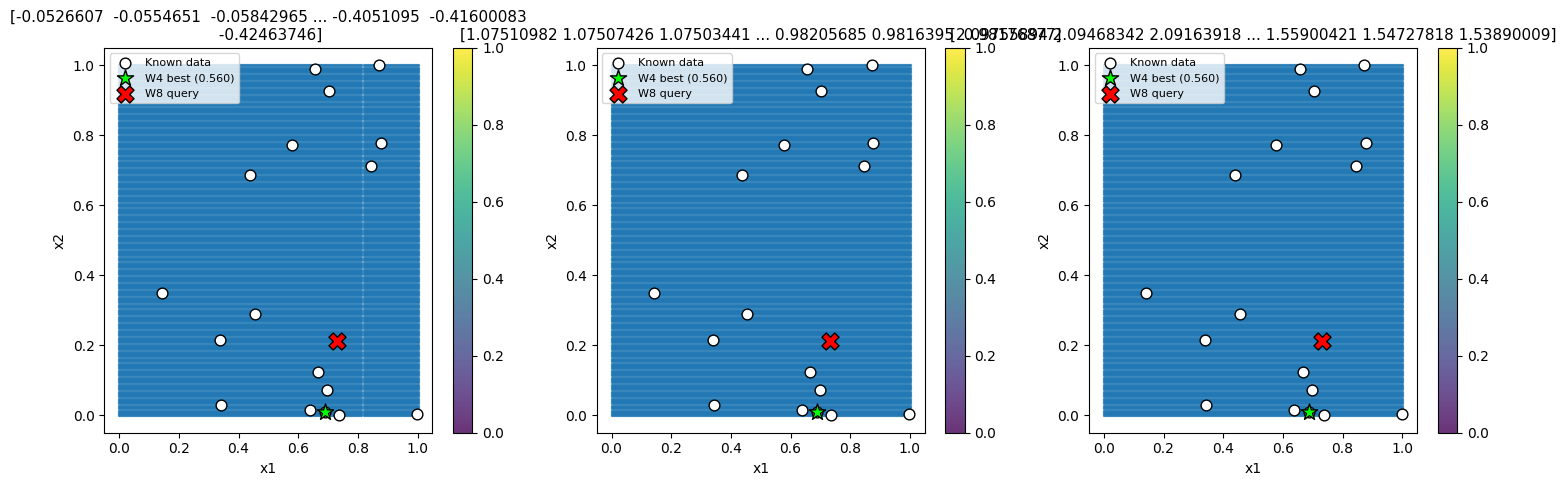

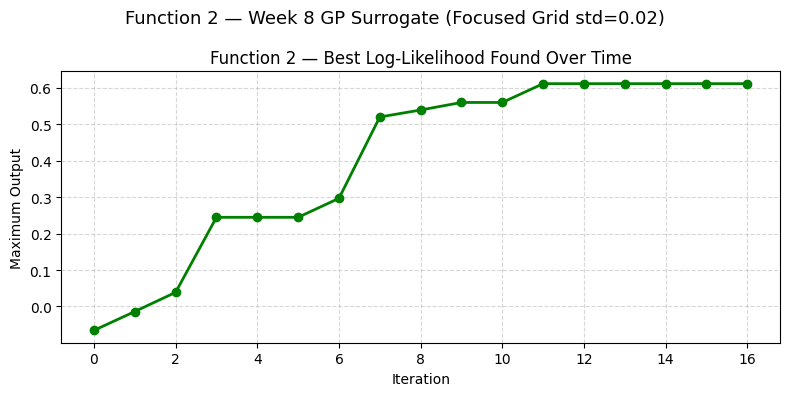

In [5]:
x_plot = np.array(np.meshgrid(
    np.linspace(0, 1, 150),
    np.linspace(0, 1, 150)
)).T.reshape(-1, 2)

mu_grid, sigma_grid = model.predict(x_plot, return_std=True)
ucb_plot = mu_grid + 2.0 * sigma_grid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles   = ['GP Mean (Transformed)', 'GP Uncertainty (Sigma)', 'UCB Acquisition Surface']
surfaces = [mu_grid, sigma_grid, ucb_plot]
cmaps    = ['viridis', 'plasma', 'inferno']

for ax, surface, title, cmap in zip(axes, titles, surfaces, cmaps):
    sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], cmap=cmap, s=2, alpha=0.8)
    ax.scatter(X_unique[:, 0], X_unique[:, 1],
               c='white', edgecolors='black', s=60, zorder=5, label='Known data')
    ax.scatter(w4_best[0], w4_best[1],
               c='lime', edgecolors='black', s=150, zorder=6, marker='*', label='W4 best (0.560)')
    ax.scatter(next_query[0], next_query[1],
               c='red', edgecolors='black', s=150, zorder=7, marker='X', label='W8 query')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.colorbar(sc, ax=ax)
    ax.legend(fontsize=8)

running_max = np.maximum.accumulate(Y_updated)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(running_max, marker='o', color='green', linewidth=2)
ax2.set_title('Function 2 — Best Log-Likelihood Found Over Time')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Maximum Output')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 2 — Week 8 GP Surrogate (Focused Grid std=0.02)', fontsize=13)
plt.tight_layout()
plt.show()